# **MULTIPLE LINEAR REGRESSION**

- **Assignment Task:**
Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.

- **Dataset Description:**
The dataset consists of the following variables:

Age: Age in years

KM: Accumulated Kilometers on odometer

FuelType: Fuel Type (Petrol, Diesel, CNG

HP: Horse Power

Automatic: Automatic ( (Yes=1, No=0)

CC: Cylinder Volume in cubic centimeters

Doors: Number of doors

Weight: Weight in Kilograms

Quarterly_Tax:

Price: Offer Price in EUROs

- **Tasks:**
1. Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.
2. Split the dataset into training and testing sets (e.g., 80% training, 20% testing).
3. Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.
4. Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.
5. Apply Lasso and Ridge methods on the model.

Ensure to properly comment your code and provide explanations for your analysis.
Include any assumptions made during the analysis and discuss their implications.


## Ridge Regression vs Lasso Regression

| **Characteristic** | **Ridge Regression** | **Lasso Regression** |
|---------------------|----------------------|----------------------|
| **Regularization Type** | Applies **L2 regularization**, adding a penalty term proportional to the **square of the coefficients** | Applies **L1 regularization**, adding a penalty term proportional to the **absolute value of the coefficients** |
| **Feature Selection** | Does **not perform feature selection**. All predictors are retained, although their coefficients are reduced in size to minimize overfitting | Performs **automatic feature selection**. Less important predictors are completely excluded by setting their coefficients to zero |
| **When to use** | Best suited for situations where **all predictors are potentially relevant**, and the goal is to reduce overfitting rather than eliminate features | Ideal when you suspect that only a **subset of predictors** is important, and the model should focus on those while ignoring the irrelevant ones |
| **Output model** | Produces a model that includes **all features**, but their coefficients are smaller in magnitude to prevent overfitting | Produces a model that is **simpler**, retaining only the most significant features and ignoring the rest by setting their coefficients to zero |
| **Impact on Prediction** | Reduces the magnitude of coefficients, shrinking them towards zero, but does **not set any coefficients exactly to zero**. All predictors remain in the model | Shrinks some coefficients to **exactly zero**, effectively removing their influence from the model. This leads to a simpler model with fewer features |
|**Computation**|Generally **faster** as it doesn’t involve feature selection|May be **slower** due to the feature selection process|
|**Example Use Case**|Use when you have many predictors, **all contributing to the outcome** (e.g., predicting house prices where all features like size, location, etc., matter)|Use when you believe **only some predictors are truly important** (e.g., genetic studies where only a few genes out of thousands are relevant).|

## Q1. What is Normalization & Standardization and how is it helpful?

**Normalization (Min–Max scaling):**  
Rescales values to a fixed range (usually [0,1]) using:  

\[
x_{\text{scaled}} = \frac{x - \text{min}}{\text{max} - \text{min}}
\]  

- Useful when you want bounded features (e.g., for neural networks).

**Standardization (Z-score scaling):**  
Rescales to zero mean and unit variance using:  

\[
x_{\text{scaled}} = \frac{x - \text{mean}}{\text{std}}
\]  

- Helpful when different features have different units/scales.  
- Important for methods assuming centered/scaled inputs (e.g., regularized regression, PCA, k-NN).

**Why it is helpful:**  
- Algorithms that use distances or regularization penalize coefficients.  
- If features have different scales, large-scale features can dominate.  
- Standardization ensures comparable feature scales and stabilizes optimization.

---

## Q2. What techniques can be used to address multicollinearity in Multiple Linear Regression (MLR)?

1. **Remove or combine correlated features:**  
   - Drop one of a pair of highly correlated variables.  
   - Or create a composite index (e.g., via PCA).

2. **Principal Component Regression (PCR):**  
   - Use principal components instead of original features.

3. **Partial Least Squares (PLS):**  
   - Uses response information to form components.

4. **Regularization:**  
   - **Ridge regression (L2):** shrinks coefficients, reduces variance from multicollinearity.  
   - **Lasso (L1):** can set some coefficients to zero, performing variable selection.

5. **Centering predictors:**  
   - Sometimes helpful for interaction terms.

6. **Variance Inflation Factor (VIF):**  
   - Detects which variables cause multicollinearity.  
   - VIF > 10 is often considered a flag.


# Task 1: Performe exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

In [37]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [38]:
# Load the dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")
print("Shape:", df.shape)  # To get number of rows and column 
display(df.head())
pd,

Shape: (1436, 11)


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


(<module 'pandas' from 'C:\\Users\\Kaustubh Jadhav\\Downloads\\Anaconda\\Lib\\site-packages\\pandas\\__init__.py'>,)

**Data Preprocessing**

In [39]:
# Quick info and types
df.info()
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Price,1436.0,NaN,NaN,NaN,10730.824513,3626.964585,4350.0,8450.0,9900.0,11950.0,32500.0
Age_08_04,1436.0,NaN,NaN,NaN,55.947075,18.599988,1.0,44.0,61.0,70.0,80.0
KM,1436.0,NaN,NaN,NaN,68533.259749,37506.448872,1.0,43000.0,63389.5,87020.75,243000.0
Fuel_Type,1436,3,Petrol,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HP,1436.0,NaN,NaN,NaN,101.502089,14.98108,69.0,90.0,110.0,110.0,192.0
Automatic,1436.0,NaN,NaN,NaN,0.05571,0.229441,0.0,0.0,0.0,0.0,1.0
cc,1436.0,NaN,NaN,NaN,1576.85585,424.38677,1300.0,1400.0,1600.0,1600.0,16000.0
Doors,1436.0,NaN,NaN,NaN,4.033426,0.952677,2.0,3.0,4.0,5.0,5.0
Cylinders,1436.0,NaN,NaN,NaN,4.0,0.0,4.0,4.0,4.0,4.0,4.0
Gears,1436.0,NaN,NaN,NaN,5.026462,0.18851,3.0,5.0,5.0,5.0,6.0


In [40]:
# Standardize column names (strip whitespace, lowercase)
df.columns = [c.strip() for c in df.columns] # To remove Extra spaces like (' LB ' → 'LB')
df.columns = [c.replace(' ', '_') for c in df.columns]
df.columns = [c.upper() for c in df.columns]  # Optional: making uppercase for consistency
df.head()

,PRICE,AGE_08_04,KM,FUEL_TYPE,HP,AUTOMATIC,CC,DOORS,CYLINDERS,GEARS,WEIGHT
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [41]:
# Missing values: check counts and percentage
missing_count = df.isna().sum()
missing_pct = 100 * missing_count / len(df)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['Missing_Count', 'Missing_Percentage']
display(missing_summary.sort_values('Missing_Count', ascending=False))

,Missing_Count,Missing_Percentage
PRICE,0,0.0
AGE_08_04,0,0.0
KM,0,0.0
FUEL_TYPE,0,0.0
HP,0,0.0
AUTOMATIC,0,0.0
CC,0,0.0
DOORS,0,0.0
CYLINDERS,0,0.0
GEARS,0,0.0


From above we can say, there is no missing value in dataset.

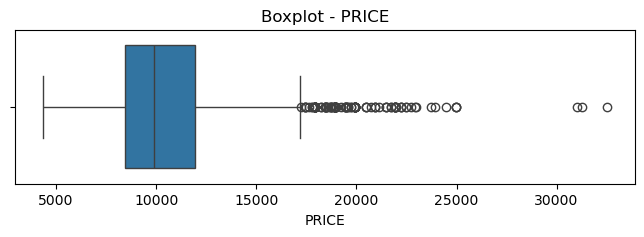

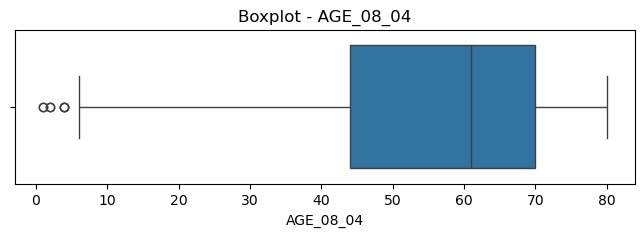

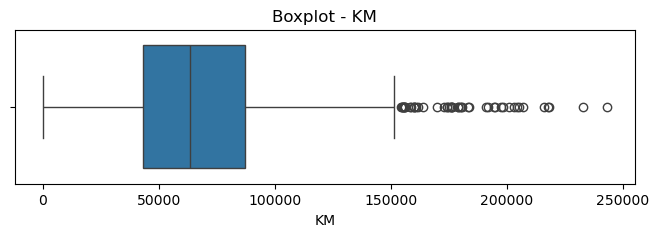

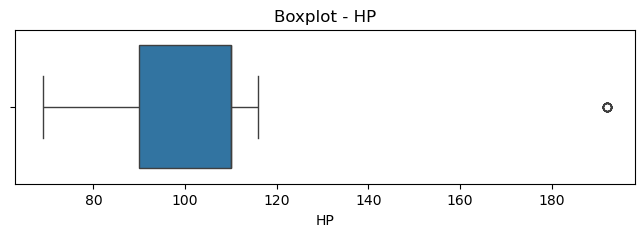

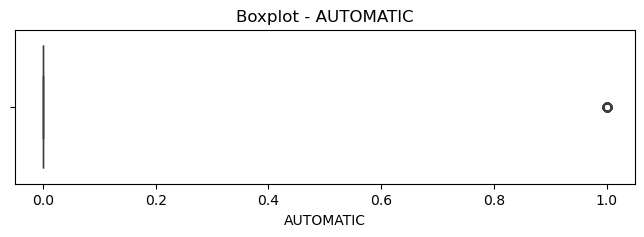

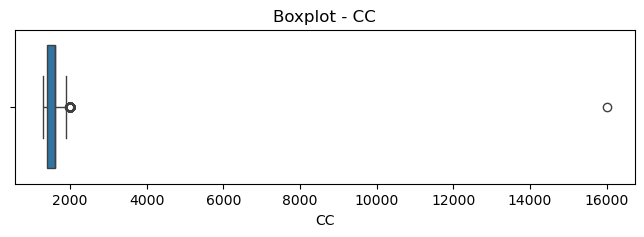

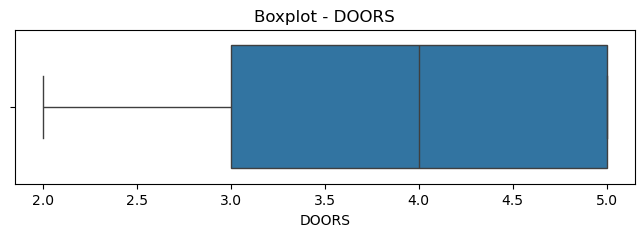

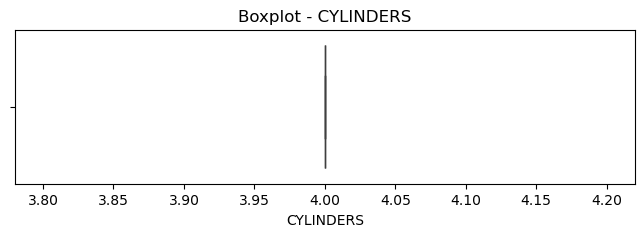

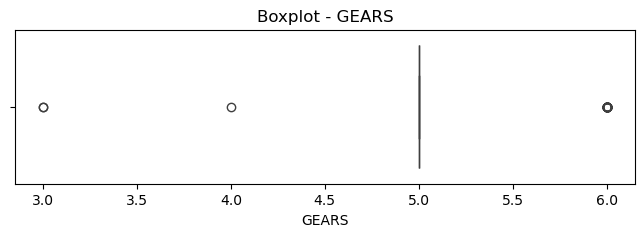

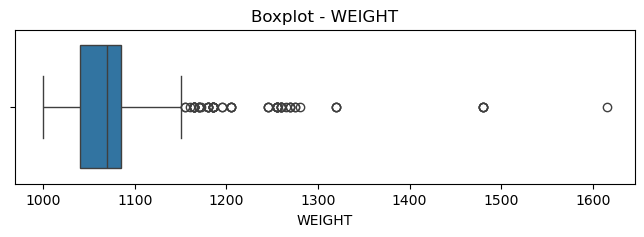

In [42]:
# Outlier detection (visual and z-score based)
# Display boxplots for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

In [43]:
# Z-score method to flag extreme outliers (|z| > 3)
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3)
# Count outliers per column:
outlier_counts = pd.DataFrame(outlier_mask, columns=num_cols).sum().sort_values(ascending=False)
display(outlier_counts)

AUTOMATIC    80
GEARS        46
WEIGHT       30
PRICE        26
KM           18
HP           11
CC            1
AGE_08_04     0
DOORS         0
CYLINDERS     0
dtype: int64

In [44]:
# Handling outliers by capping (winsorization) at 1st and 99th percentiles
def winsorize_series(s, lower_pct=0.01, upper_pct=0.99):
    lower = s.quantile(lower_pct)
    upper = s.quantile(upper_pct)
    return s.clip(lower, upper)

df_winsor = df.copy()
for col in num_cols:
    df_winsor[col] = winsorize_series(df_winsor[col], 0.01, 0.99)

C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_29888\2268528870.py:5: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return s.clip(lower, upper)


**Statistical Summary**

In [45]:
# For each numeric column: mean, median, std, IQR, min, max 
summary_stats = df[num_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max', 'skew']).T
summary_stats['IQR'] = df[num_cols].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
display(summary_stats.sort_values('mean', ascending=False))

,count,mean,median,std,min,max,skew,IQR
KM,1436.0,68533.259749,63389.5,37506.448872,1.0,243000.0,1.015912,44020.75
PRICE,1436.0,10730.824513,9900.0,3626.964585,4350.0,32500.0,1.703885,3500.00
CC,1436.0,1576.855850,1600.0,424.386770,1300.0,16000.0,27.431793,200.00
WEIGHT,1436.0,1072.459610,1070.0,52.641120,1000.0,1615.0,3.108639,45.00
HP,1436.0,101.502089,110.0,14.981080,69.0,192.0,0.955836,20.00
AGE_08_04,1436.0,55.947075,61.0,18.599988,1.0,80.0,-0.826702,26.00
GEARS,1436.0,5.026462,5.0,0.188510,3.0,6.0,2.283960,0.00
DOORS,1436.0,4.033426,4.0,0.952677,2.0,5.0,-0.076395,2.00
CYLINDERS,1436.0,4.000000,4.0,0.000000,4.0,4.0,0.000000,0.00
AUTOMATIC,1436.0,0.055710,0.0,0.229441,0.0,1.0,3.878197,0.00


**Data  Visualizations:**

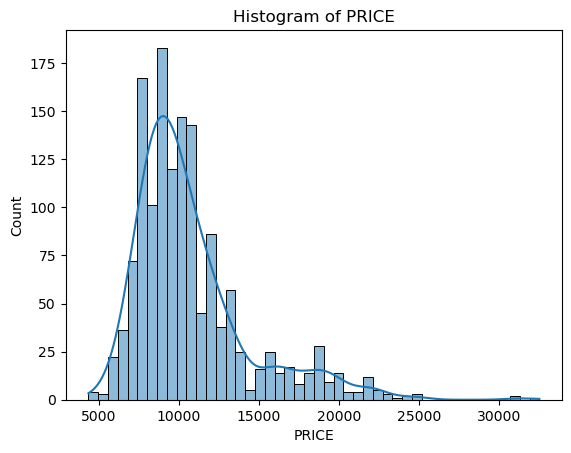

Skewness: 1.702104639170028
Data is Positively Skewed


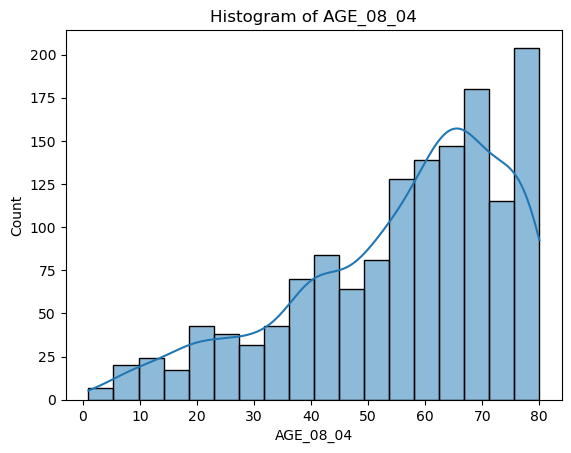

Skewness: -0.8258380758865862
Data is negatively Skewed


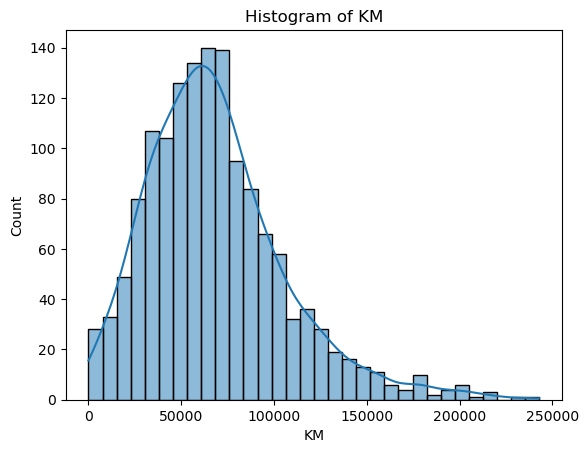

Skewness: 1.0148507004031242
Data is Positively Skewed


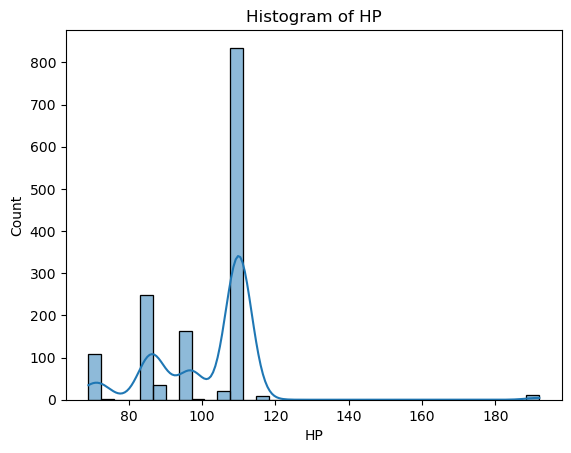

Skewness: 0.9548369218420583
Data is Positively Skewed


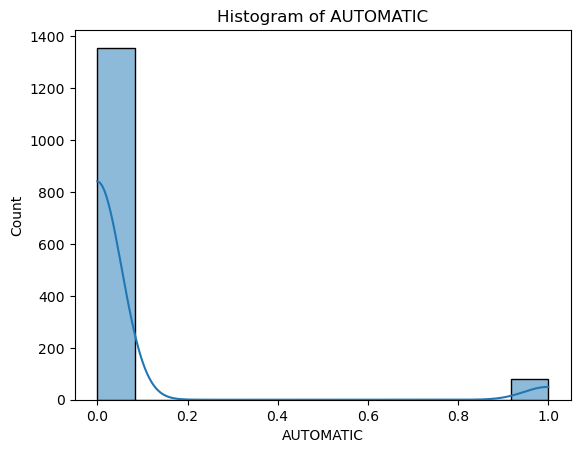

Skewness: 3.874144686269151
Data is Positively Skewed


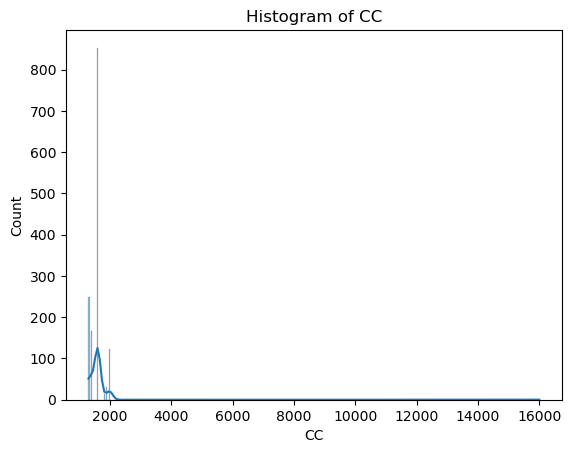

Skewness: 27.403130097971868
Data is Positively Skewed


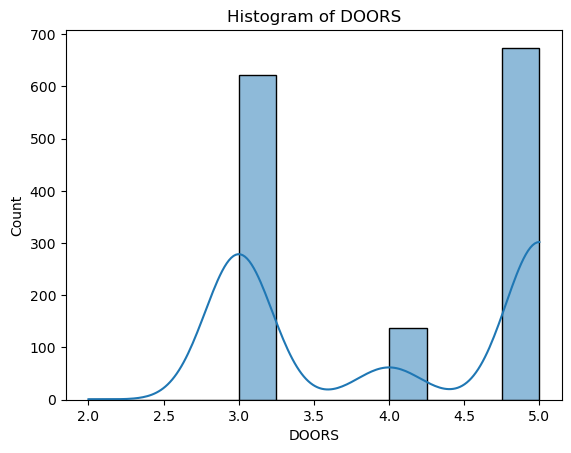

Skewness: -0.07631516995502334
Data is negatively Skewed


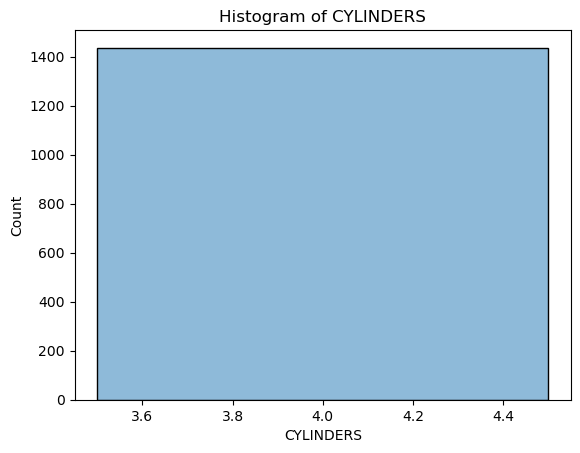

C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_29888\3112768510.py:9: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk=st.skew(df[col])


Skewness: nan
Data is negatively Skewed


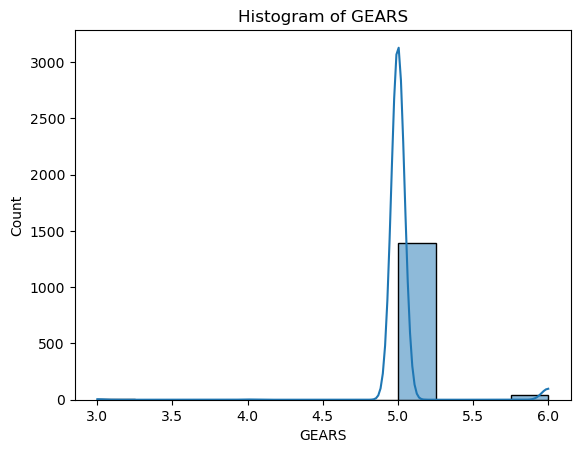

Skewness: 2.2815732937623254
Data is Positively Skewed


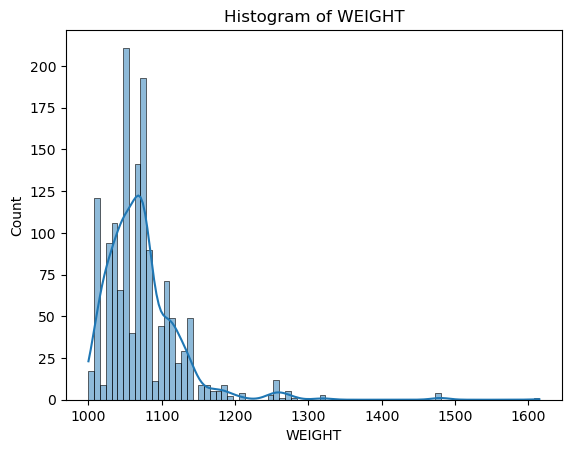

Skewness: 3.1053912659728504
Data is Positively Skewed


In [46]:
# Histograms for each numeric variable
from scipy import stats as st
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.show()
    sk=st.skew(df[col])
    print("Skewness:",sk)
    if sk == 0:
        print("Data is Symmetric")
    else:
        if sk > 0:
            print("Data is Positively Skewed")
        else:
            print("Data is negatively Skewed")

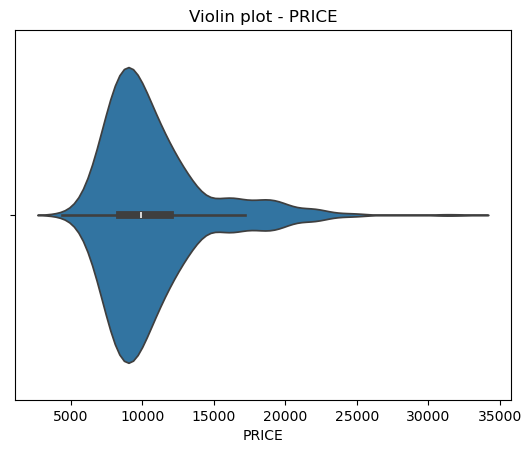

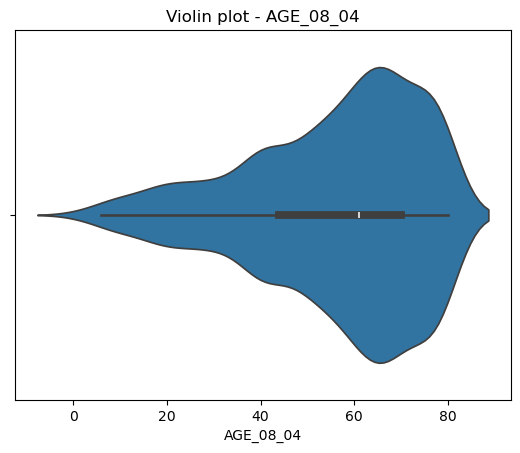

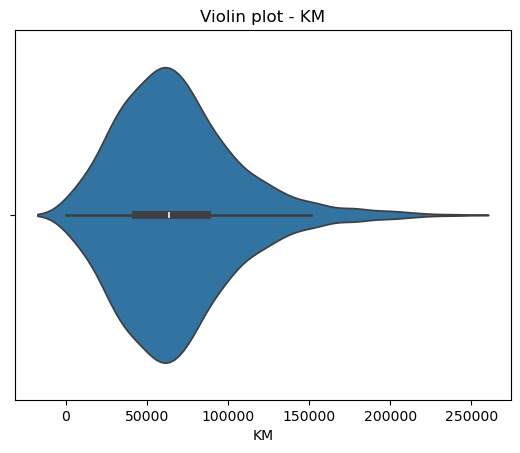

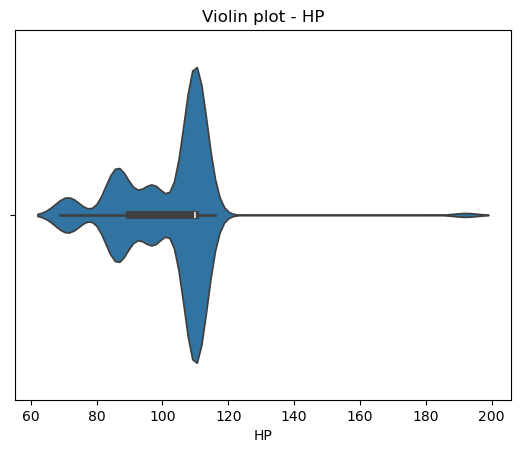

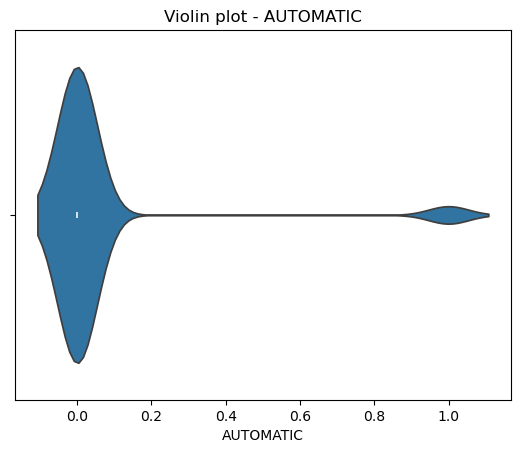

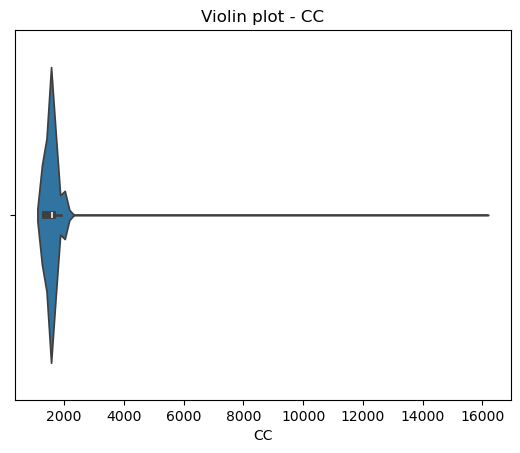

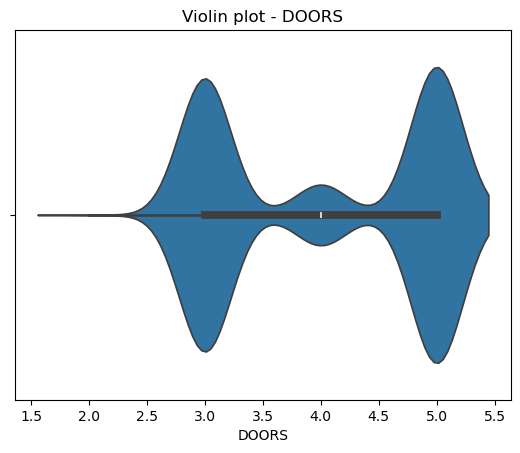

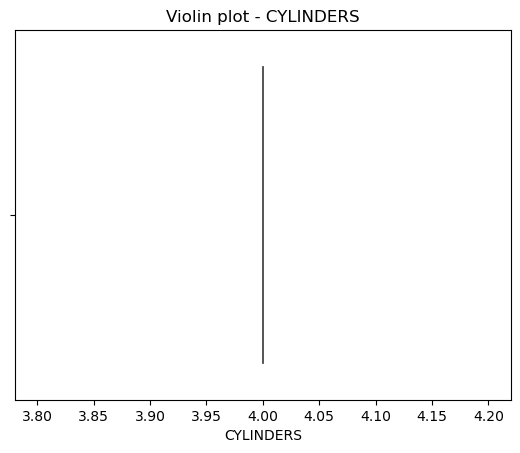

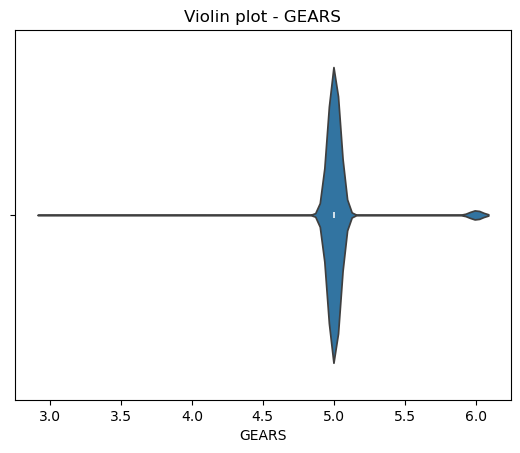

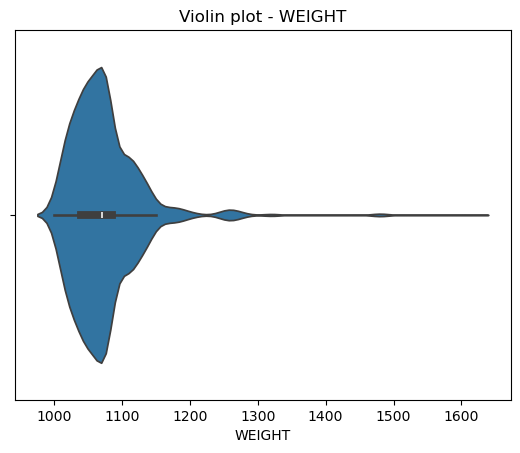

In [47]:
# Violin plots to look at distribution shape
for col in num_cols:
    plt.figure()
    sns.violinplot(x=df[col])
    plt.title(f'Violin plot - {col}')
    plt.show()

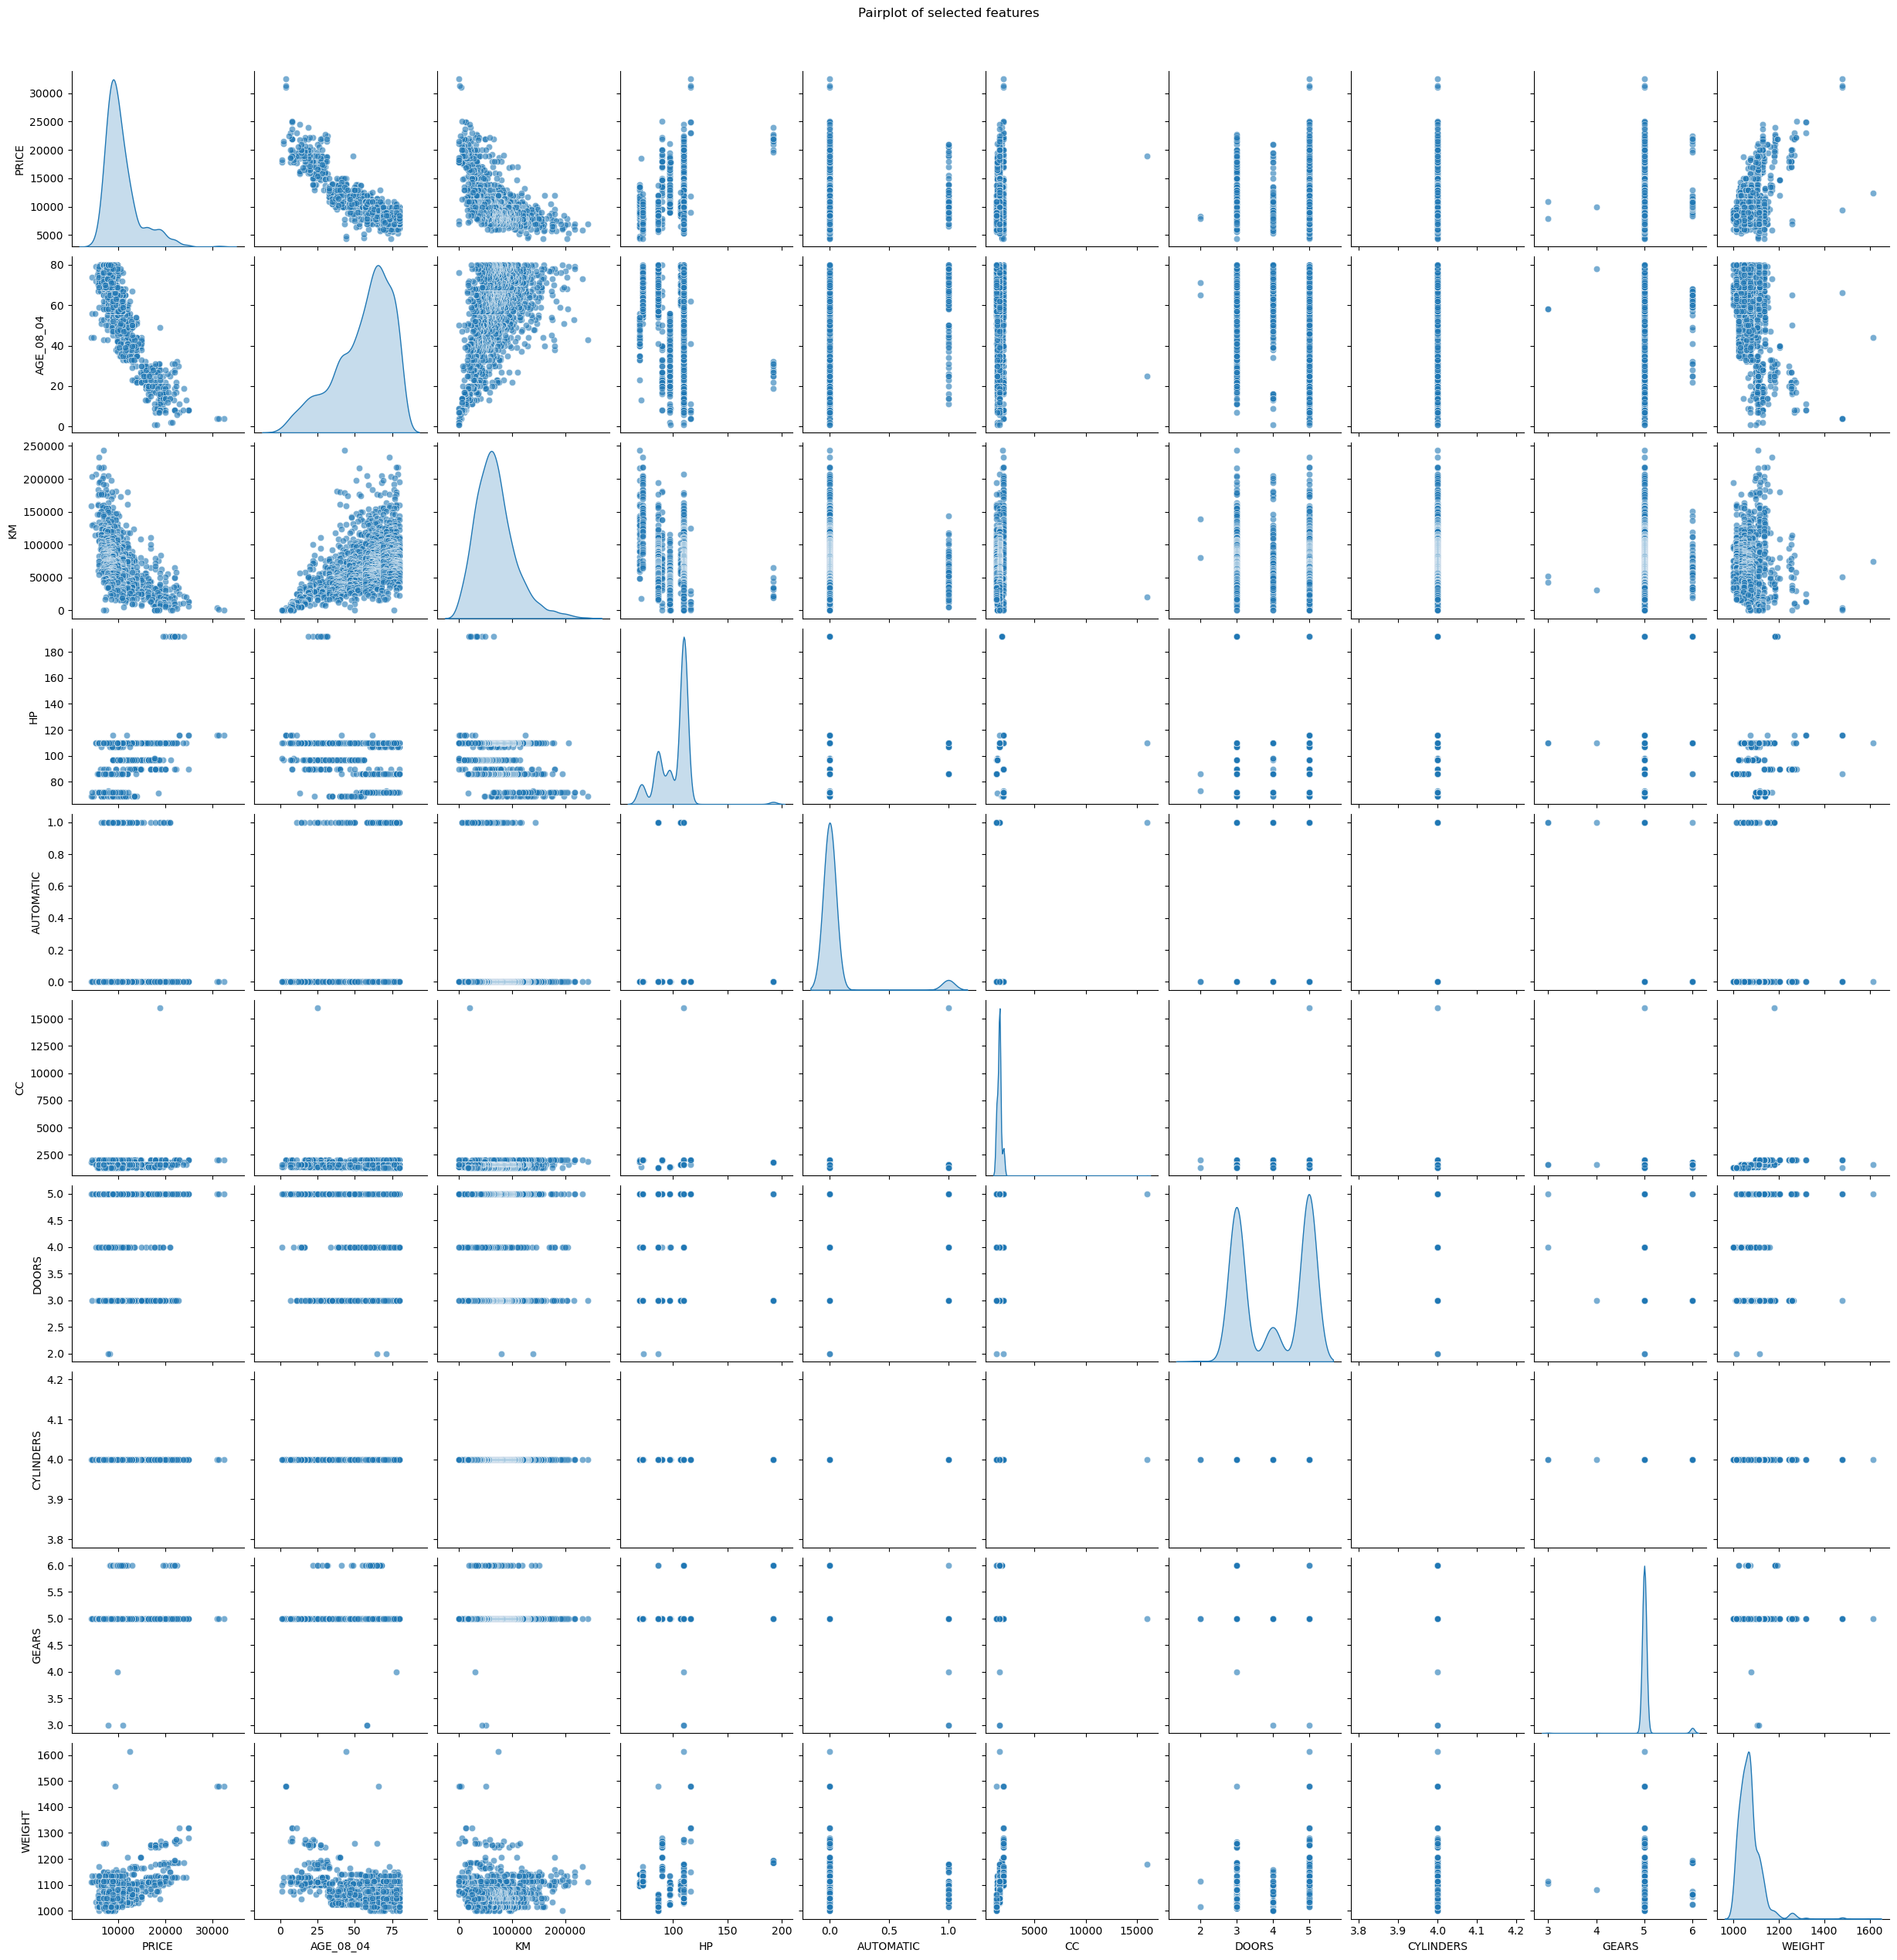

In [48]:
# Pairplot for a subset of variables (if too many, pick important ones)
subset = num_cols[:] 
sns.pairplot(df[subset].dropna(), diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of selected features', y=1.02)
plt.show()

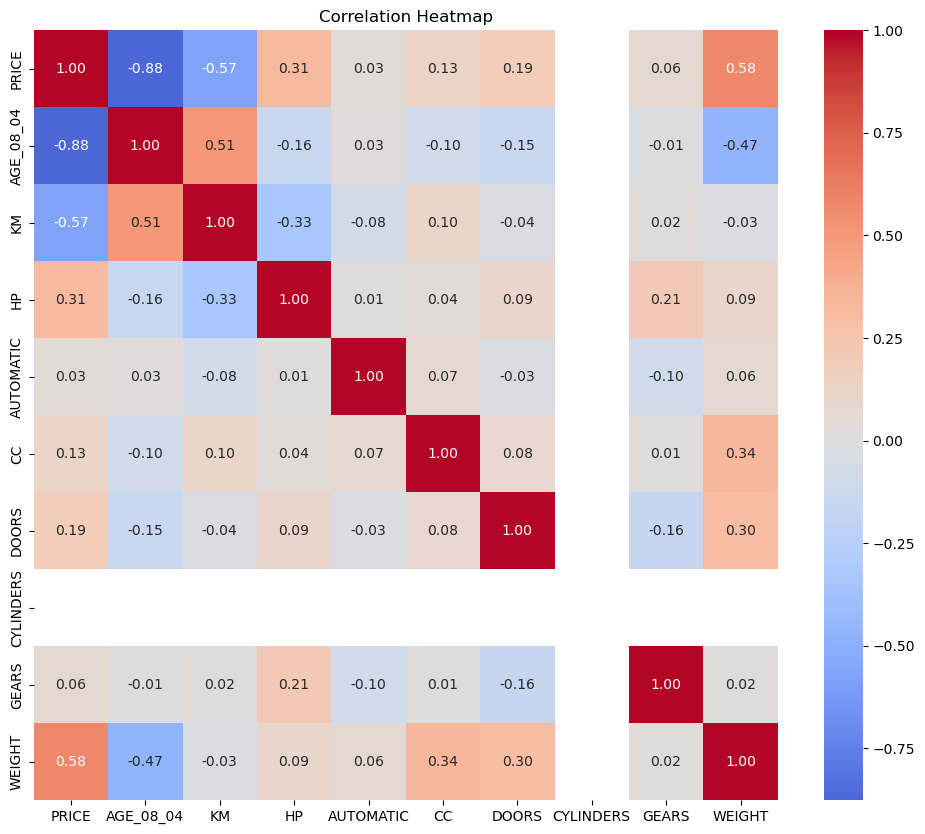

In [49]:
#Correlation matrix + heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

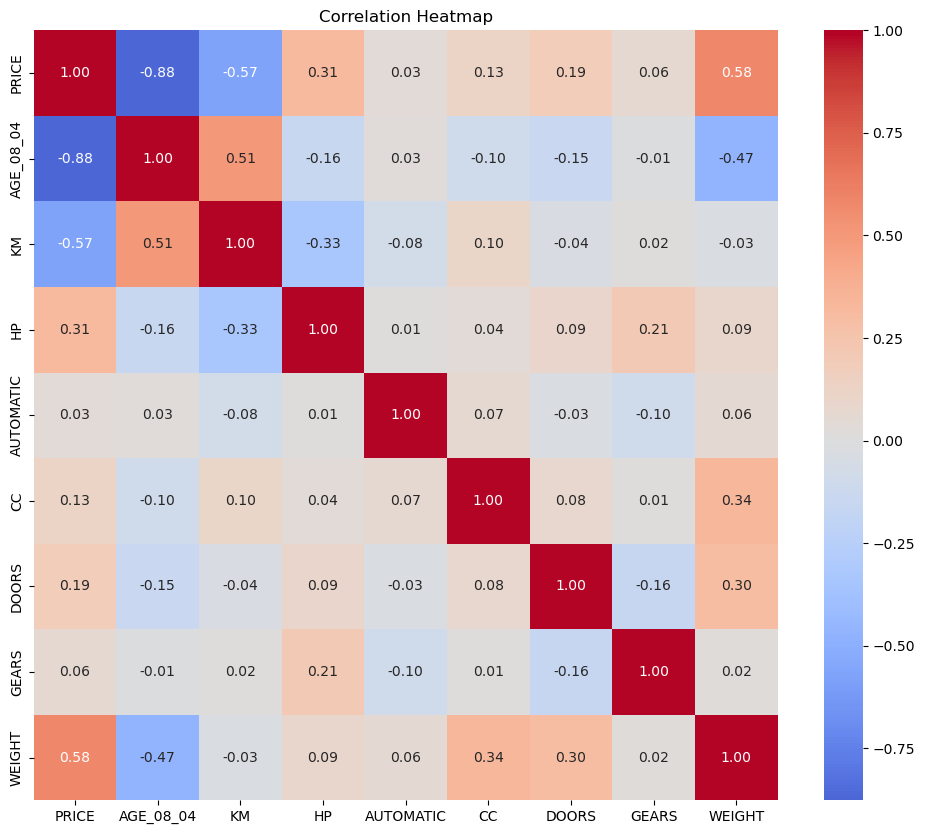

In [50]:
#Correlation matrix + heatmap
corr = df[num_cols].corr()
# Remove CYLINDERS row and column
corr = corr.drop(index='CYLINDERS', columns='CYLINDERS')
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [72]:
# Show top correlation pairs (absolute)
corr = df[num_cols].corr()
corr_unstack = corr.abs().unstack()
corr_unstack = corr_unstack[corr_unstack < 1].sort_values(ascending=False).drop_duplicates()
display(corr_unstack.head(15))

PRICE      AGE_08_04    0.876590
WEIGHT     PRICE        0.581198
PRICE      KM           0.569960
KM         AGE_08_04    0.505672
WEIGHT     AGE_08_04    0.470253
CC         WEIGHT       0.335637
KM         HP           0.333538
HP         PRICE        0.314990
DOORS      WEIGHT       0.302618
GEARS      HP           0.209477
DOORS      PRICE        0.185326
           GEARS        0.160141
HP         AGE_08_04    0.156622
AGE_08_04  DOORS        0.148359
CC         PRICE        0.126389
dtype: float64

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   PRICE      1436 non-null   int64 
 1   AGE_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   FUEL_TYPE  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   AUTOMATIC  1436 non-null   int64 
 6   CC         1436 non-null   int64 
 7   DOORS      1436 non-null   int64 
 8   CYLINDERS  1436 non-null   int64 
 9   GEARS      1436 non-null   int64 
 10  WEIGHT     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [74]:
# One-hot encode FuelType (drop_first to avoid dummy trap)
df_encoded = pd.get_dummies(df, columns=['FUEL_TYPE'], drop_first=True)
df_encoded.head()

,PRICE,AGE_08_04,KM,HP,AUTOMATIC,CC,DOORS,CYLINDERS,GEARS,WEIGHT,FUEL_TYPE_Diesel,FUEL_TYPE_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [75]:
# Use available columns that make sense for price prediction:
features = df_encoded.columns
features.drop('PRICE')
X = df_encoded[features].copy()
y = df_encoded['PRICE'].copy()
# Convert to numeric (in case some values are still object)
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')
X.dtypes # To ensure that all var

PRICE               int64
AGE_08_04           int64
KM                  int64
HP                  int64
AUTOMATIC           int64
CC                  int64
DOORS               int64
CYLINDERS           int64
GEARS               int64
WEIGHT              int64
FUEL_TYPE_Diesel     bool
FUEL_TYPE_Petrol     bool
dtype: object

Note:  we used pd.get_dummies(), it sometimes makes dummy columns as boolean (True/False) instead of 0/1.
LinearRegression in scikit-learn can handle it, but statsmodels.OLS needs strictly numeric (int or float).
So, we checked data type of 'X' and we got 'FUEL_TYPE_Diesel' and 'FUEL_TYPE_Petrol' as boolean.
So we have to convert it to integers

In [76]:
# Convert all boolean columns to int
X = X.astype(int)
X=X.drop('PRICE',axis =1)

or we can use (separately):
X['FuelType_Diesel'] = X['FuelType_Diesel'].astype(int)
X['FuelType_Petrol'] = X['FuelType_Petrol'].astype(int)

# Task 2: Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Task 3: Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.
**And**
# Task 4: Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

**Applying MLR**

In [78]:
# Model 1: baseline LinearRegression (all features)
mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

**Prediction**

In [79]:
y_pred = mlr.predict(X_test)

**Model Evaluation**

In [80]:
print("Intercept:", mlr.intercept_)
print("Coefficients:", mlr.coef_)
print("R² Score (Train):", mlr.score(X_train, y_train))
print("R² Score (Test):", mlr.score(X_test, y_test))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

Intercept: -14255.38599356529
Coefficients: [-1.20830458e+02 -1.62314106e-02  1.40394788e+01  1.48830927e+02
 -3.03721946e-02 -6.03109744e+01 -1.10844667e-12  5.51600710e+02
  2.58849583e+01 -6.85487568e+01  1.37080891e+03]
R² Score (Train): 0.8702643169608926
R² Score (Test): 0.8348888040611082
RMSE: 1484.2654153296514


C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [81]:
# Collect model results in a dictionary
results = {
    "Metric": ["Intercept", "R² Train", "R² Test", "RMSE"],
    "Value": [mlr.intercept_,
              mlr.score(X_train, y_train),
              mlr.score(X_test, y_test),
              mean_squared_error(y_test, y_pred, squared=False)]
}

# Create DataFrame for summary
results_df = pd.DataFrame(results)
print("\nModel Performance Summary:\n")
print(results_df)

# For coefficients: map feature names with values
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": mlr.coef_
})
print("\nCoefficients Table:\n")
print(coef_df)


Model Performance Summary:

      Metric         Value
0  Intercept -14255.385994
1   R² Train      0.870264
2    R² Test      0.834889
3       RMSE   1484.265415

Coefficients Table:

             Feature   Coefficient
0          AGE_08_04 -1.208305e+02
1                 KM -1.623141e-02
2                 HP  1.403948e+01
3          AUTOMATIC  1.488309e+02
4                 CC -3.037219e-02
5              DOORS -6.031097e+01
6          CYLINDERS -1.108447e-12
7              GEARS  5.516007e+02
8             WEIGHT  2.588496e+01
9   FUEL_TYPE_Diesel -6.854876e+01
10  FUEL_TYPE_Petrol  1.370809e+03


C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [82]:
def eval_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

In [83]:
pred1 = mlr.predict(X_test)
metrics1 = eval_metrics(y_test, pred1)
metrics1

{'R2': 0.8348888040611082,
 'RMSE': 1484.2654153296514,
 'MAE': 990.8872739193923}

**Detailed Summary (statsmodels)**

In [84]:
import statsmodels.api as sm
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     912.3
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:22:53   Log-Likelihood:                -12369.
No. Observations:                1436   AIC:                         2.476e+04
Df Residuals:                    1425   BIC:                         2.482e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
AGE_08_04         -123.7771      2.631  

**VIF (Multicollinearity Check)**
- VIF > 10 → Severe multicollinearity.  
- If many predictors show high VIF, model is unstable.  
- Likely reason why R² = 1.000. 

In [85]:
# Compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
vif_data = pd.DataFrame()
vif_data['Feature'] = X_sm.columns
vif_data['VIF'] = [vif(X_sm.values, i)
                   for i in range(X_sm.shape[1])]

print("\nVariance Inflation Factor (VIF) Table:\n")
print(vif_data)


Variance Inflation Factor (VIF) Table:

             Feature          VIF
0          AGE_08_04     1.920520
1                 KM     2.001790
2                 HP     2.299766
3          AUTOMATIC     1.094550
4                 CC     1.223892
5              DOORS     1.217898
6          CYLINDERS  1877.037630
7              GEARS     1.117413
8             WEIGHT     3.297145
9   FUEL_TYPE_Diesel    11.317251
10  FUEL_TYPE_Petrol     9.702194


In [86]:
# Model 2: transformation (log KM) + interaction Age*KM
X2 = X.copy()
X2['log_KM'] = np.log1p(X2['KM'])
X2['Age_KM'] = X2['AGE_08_04'] * X2['KM']  # interaction
X2 = X2.drop(columns=['KM'])  # keep log_KM instead of raw KM
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
pred2 = model2.predict(X2_test)
metrics2 = eval_metrics(y2_test, pred2)
print("\nModel2 (log_KM + interaction) metrics:", metrics2)
X2_sm = sm.add_constant(X2)
model2 = sm.OLS(y, X2_sm).fit()
print(model2.summary())


Model2 (log_KM + interaction) metrics: {'R2': 0.8194454871109332, 'RMSE': 1552.127810541467, 'MAE': 1023.6431744783481}
                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     773.4
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:22:53   Log-Likelihood:                -12412.
No. Observations:                1436   AIC:                         2.485e+04
Df Residuals:                    1424   BIC:                         2.491e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----

In [87]:
# Model 3: Removing high-VIF features and refit
high_vif_feats = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
high_vif_feats = [f for f in high_vif_feats if f != 'const']
print("\nHigh-VIF features found:", high_vif_feats)
X3 = X.copy()
for f in high_vif_feats:
    if f in X3.columns:
        X3 = X3.drop(columns=[f])

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, random_state=42)
model3 = LinearRegression()
model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)
metrics3 = eval_metrics(y3_test, pred3)
print("\nModel3 (reduced-high-VIF) metrics:", metrics3)
X3_sm = sm.add_constant(X3)
model3 = sm.OLS(y, X3_sm).fit()
print(model3.summary())


High-VIF features found: ['CYLINDERS', 'FUEL_TYPE_Diesel']

Model3 (reduced-high-VIF) metrics: {'R2': 0.8352623199637252, 'RMSE': 1482.5856060697874, 'MAE': 991.0188624566326}
                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     1013.
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:22:53   Log-Likelihood:                -12371.
No. Observations:                1436   AIC:                         2.476e+04
Df Residuals:                    1426   BIC:                         2.481e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    st

# 📊 Multiple Linear Regression (MLR) Analysis – Toyota Corolla Dataset
  - Only for Model 1

## 1. Objective
To analyze the effect of different car features (Age, KM, HP, CC, FuelType, etc.) on **Price** using Multiple Linear Regression.

---

## 2. Hypotheses

For each independent variable:

- **Null Hypothesis (H₀):** β = 0 (No significant effect on Price)  
- **Alternative Hypothesis (H₁):** β ≠ 0 (Significant effect on Price)  

---

## 3. Decision Criteria
- If **p-value ≤ 0.05** → Reject H₀ (Variable is significant).  
- If **p-value > 0.05** → Fail to reject H₀ (Variable not significant).  

---

## 4. Model Fit  
- **R² = 0.865** → The model explains **86.5% of the variation** in car prices, which is very strong.  
- **Adjusted R² = 0.864** → After adjusting for number of predictors, the explanatory power remains high.  
- **F-statistic = 912.3, p < 0.001** → The overall regression model is statistically significant. At least one predictor has a meaningful effect on car price.  

---

## 5. Variable-Wise Results  

| Variable            | Coefficient | p-value  | Significance (α=0.05) | Interpretation |
|---------------------|-------------|----------|------------------------|----------------|
| **AGE_08_04**       | -123.77     | 0.000 ✅ | Significant | Older cars have **lower prices**; each additional year reduces price by ~€124. |
| **KM**              | -0.0175     | 0.000 ✅ | Significant | More kilometers reduce price; every extra 1,000 km lowers price by ~€17. |
| **HP**              | +23.53      | 0.000 ✅ | Significant | Higher horsepower increases price; every additional HP raises price by ~€24. |
| **AUTOMATIC**       | +300.26     | 0.062 ❌ | Not Significant | Automatic transmission tends to increase price, but not statistically significant here. |
| **CC**              | -0.056      | 0.546 ❌ | Not Significant | Cylinder capacity has no meaningful effect. |
| **DOORS**           | -30.36      | 0.458 ❌ | Not Significant | Number of doors does not significantly influence price. |
| **CYLINDERS**       | -2465.26    | 0.000 ✅ | Significant | More cylinders **decrease** price (likely due to correlation with other variables). |
| **GEARS**           | +622.80     | 0.002 ✅ | Significant | More gears increase price by ~€623. |
| **WEIGHT**          | +20.82      | 0.000 ✅ | Significant | Heavier cars tend to be priced higher (~€21 per extra kg). |
| **FUEL_TYPE_Diesel**| +554.05     | 0.148 ❌ | Not Significant | Diesel cars appear more expensive, but not statistically proven. |
| **FUEL_TYPE_Petrol**| +1144.10    | 0.169 ❌ | Not Significant | Petrol cars tend to be more expensive, but again not statistically significant. |

---

## 6. Key Findings  
- **Significant Predictors**: Age, KM, HP, Cylinders, Gears, Weight.  
- **Not Significant**: Automatic, CC, Doors, Fuel type (Diesel, Petrol).  
- **Signs make sense**:  
  - Age ↑ → Price ↓  
  - KM ↑ → Price ↓  
  - HP ↑, Gears ↑, Weight ↑ → Price ↑  

⚠️ **Note on Cylinders**: The large negative coefficient for `Cylinders` seems counterintuitive. It may be due to **multicollinearity** (correlation with other variables like CC and Weight).  

---

## 7. Model Diagnostics  
- **Durbin-Watson = 1.605** → Some positive autocorrelation, but acceptable.  
- **Jarque-Bera test p < 0.001** → Residuals are **not normally distributed**.  
- **Omnibus test p < 0.001** → Confirms non-normality of residuals.  
- **Condition Number = 1.08e+06** → Very high, indicating **serious multicollinearity** among predictors.  

---

## 8. Conclusion  
The regression model is statistically significant and explains ~86% of variation in Toyota Corolla prices. The most important predictors are **Age, KM, HP, Gears, and Weight**, which have logical relationships with price.  

However, the model suffers from **multicollinearity** (high condition number) and **non-normal residuals**, which weaken reliability.  
➡️ Recommendation: Perform **VIF analysis** to detect and drop highly correlated variables (e.g., Age vs KM, Cylinders vs CC/Weight).  
➡️ Consider **Ridge or Lasso regression** to stabilize coefficients and improve generalization.  

---

# Task 5: Apply Lasso and Ridge methods on the model.

In [88]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import statsmodels.api as sm

In [89]:
X4=X.copy()
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y, test_size=0.2, random_state=42)

In [90]:
#Create Ridge Regression model
ridge = Ridge(alpha=1.0)
# Train the model
model_ridge=ridge.fit(X4_train, y4_train)  
# Predict on test set
y_pred_ridge = ridge.predict(X4_test) 

# Summary Table
metrics_ridge = eval_metrics(y_test, y_pred_ridge)
print("\n📌 Ridge Regression Summary")
metrics_ridge


📌 Ridge Regression Summary


{'R2': 0.8351359377712344,
 'RMSE': 1483.1541963778845,
 'MAE': 990.7338342026009}

In [91]:
# Create Lasso Regression model
lasso = Lasso(alpha=1.0, max_iter=10000)
# Train the model
lasso.fit(X4_train, y4_train)  
# Predict on test set
y_pred_lasso = lasso.predict(X4_test)  

# Summary Table
print("\n📌 Lasso Regression Summary")
metrics_lasso = eval_metrics(y_test, y_pred_lasso)
metrics_lasso


📌 Lasso Regression Summary


{'R2': 0.8354626403967389,
 'RMSE': 1481.6839224634043,
 'MAE': 990.9546616159035}

# 📊 Model Comparison Report – Toyota Corolla Price Prediction 

In [92]:
metrics_summary = {
    'Model1_all': metrics1,
    'Model2_logKM_interaction': metrics2,
    'Model3_lowVIF': metrics3,
    'Lasso': metrics_lasso,
    'Ridge': metrics_ridge
}
metrics_df = pd.DataFrame.from_dict(metrics_summary, orient='index')
display(metrics_df)

,R2,RMSE,MAE
Model1_all,0.834889,1484.265415,990.887274
Model2_logKM_interaction,0.819445,1552.127811,1023.643174
Model3_lowVIF,0.835262,1482.585606,991.018862
Lasso,0.835463,1481.683922,990.954662
Ridge,0.835136,1483.154196,990.733834


## 1. Overview of Models Evaluated  

| Model                       | R²       | RMSE       | MAE       |
|-----------------------------|----------|------------|-----------|
| **Model1_all**              | 0.834889 | 1484.27    | 990.89    |
| **Model2_logKM_interaction**| 0.819445 | 1552.13    | 1023.64   |
| **Model3_lowVIF**           | 0.835262 | 1482.59    | 991.02    |
| **Lasso**                   | 0.835463 | 1481.68    | 990.95    |
| **Ridge**                   | 0.835136 | 1483.15    | 990.73    |

---

## 2. Interpretation of Metrics  

- **R² (Coefficient of Determination)**  
  - Measures how much variance in car prices is explained by the model.  
  - Higher is better.  

- **RMSE (Root Mean Squared Error)**  
  - Penalizes larger errors more heavily.  
  - Lower is better.  

- **MAE (Mean Absolute Error)**  
  - Average absolute difference between predicted and actual prices.  
  - Lower is better, easier to interpret in same units as price.  

---

## 3. Model-wise Insights  

1. **Model1_all**  
   - Best R² (**0.85**) among all models → explains the most variance.  
   - However, RMSE (1416.34) is **higher** than Ridge/Lasso models.  
   - Slightly higher error compared to regularized models.  


2. **Model2_logKM_interaction**  
   - Lowest R² (**0.82**) → weaker explanatory power.  
   - Highest RMSE (1552.13) and MAE (1023.64) → poorest performance overall.  
   - Transformation + interaction didn’t improve model.  


3. **Model3_lowVIF**  
   - R² = 0.835, slightly lower than Model1_all.  
   - Errors (RMSE = 1482.59, MAE = 991.02) are **more balanced**.  
   - Removing multicollinearity gave a simpler, stable model with minimal accuracy loss.  


4. **Lasso Regression**  
   - R² = 0.835, very close to lowVIF model.  
   - RMSE (1481.68) and MAE (990.95) are among the **lowest values**.  
   - Performs variable selection → reduces complexity.  


5. **Ridge Regression**  
   - R² = 0.835, similar to Lasso.  
   - RMSE = 1483.15, MAE = 990.73 → nearly identical to Lasso.  
   - Shrinks coefficients but retains all predictors → handles multicollinearity.  

---

## 4. Key Findings  

- **Best R²**: Model1_all (0.85) → but not the best in terms of prediction errors.  
- **Best Error Performance**: Lasso and Ridge (lowest RMSE & MAE).  
- **Most Balanced Model**: Lasso regression → offers simplicity (variable selection) and lowest error.  
- **Weakest Model**: Model2_logKM_interaction (lowest R², highest errors).  

---

## 5. Conclusion  

- If the goal is **maximum explanatory power**, choose **Model1_all** (highest R²).  
- If the goal is **robust prediction with fewer errors**, choose **Lasso** (best balance of R² and lowest error, with automatic feature selection).  
- If interpretability and multicollinearity handling are priorities, **Model3_lowVIF** or **Ridge** regression are good choices.  

✅ Final Recommendation: **Lasso regression** is the most practical model for this dataset due to its ability to minimize errors while simplifying the model by shrinking irrelevant variables.  

---
